In [2]:
pip install scikit-learn

In [3]:
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd
raw_data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv")

In [4]:
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid",
    "c_jail_in", "c_jail_out"
]]

df = df[df["days_b_screening_arrest"] <= 30]
df = df[df["days_b_screening_arrest"] >= -30]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]
len(df)

6172

In [7]:
numeric_features = ["priors_count"]

datetime_features = [
    "c_jail_in",
    "c_jail_out"
]

category_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
    "score_factor"
]

In [8]:
for col in datetime_features:
    df[col] = pd.to_datetime(df[col], errors="coerce")
for col in df.columns:
    if col not in numeric_features and col not in datetime_features and col != "age":
      df[col] = df[col].astype("category")

df["crime_factor"] = df["c_charge_degree"].cat.rename_categories({
    "F": "Felony",
    "M": "Misdemeanor"
})

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
    ordered=False
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"],
    ordered=False
)

df["score_factor"] = pd.Categorical(
    df["score_text"].replace({"Low": "Low", "Medium": "High", "High": "High"}),
    categories=["Low", "High"],
    ordered=False
)


/tmp/ipykernel_4716/1125964232.py:31: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["score_text"].replace({"Low": "Low", "Medium": "High", "High": "High"}),


## Preprocessing Pipeline

To prepare the COMPAS dataset for modeling, I constructed a preprocessing pipeline that separates
numeric and categorical features and applies the appropriate transformations to each.

- **Numeric feature**: `priors_count`  
  - Scaled using `StandardScaler` to normalize magnitude.

- **Categorical features**:  
  `gender_factor`, `age_factor`, `race_factor`, `crime_factor`, `score_factor`  
  - Encoded using `OneHotEncoder` with `handle_unknown="ignore"` to ensure stability when new categories appear.

The resulting `ColumnTransformer` ensures that all features are consistently transformed before being passed into the model.

In [9]:
X = df[['gender_factor', 'age_factor', 'race_factor', 'priors_count', 'crime_factor', 'score_factor']]
y = df["two_year_recid"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


### Step 1 — Fit logistic regression and gradient-boosted tree

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor_numeric_features = ['priors_count']
preprocessor_categorical_features = ['gender_factor', 'age_factor', 'race_factor', 'crime_factor', 'score_factor']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), preprocessor_numeric_features),
    ("cat", OneHotEncoder(
        handle_unknown="ignore"), preprocessor_categorical_features),
])

lr_pipeline = Pipeline([("preprocessor", preprocessor),
                        ("classifier", LogisticRegression(max_iter=1000,
                                                          random_state=42))
                       ])
lr_pipeline.fit(X_train, y_train)

gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42))
])
gbt_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor',
                                                   'score_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

## Model Construction

I trained two supervised learning models using the same preprocessing pipeline:

1. **Logistic Regression**
   - A linear baseline model.
   - Useful for interpretability and understanding directional effects of features.
   - Configured with `max_iter=1000` to ensure convergence.

2. **Gradient Boosted Trees (GBT)**
   - A non-linear ensemble model capable of capturing complex interactions.
   - Configured with:
     - `n_estimators = 200`
     - `max_depth = 4`
     - `random_state = 42`
   - Expected to outperform linear models on structured tabular data.

Both models were wrapped in a unified `Pipeline` so that preprocessing and prediction occur in a single, consistent workflow.

### Step 2 — Compare model performance by race

In [11]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []

    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):

        # Always return a 2×2 confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"],
            gdf["pred"],
            labels=[0, 1]
        ).ravel()

        # Safe FPR/FNR
        FPR = fp / (fp + tn) if (fp + tn) > 0 else 0
        FNR = fn / (fn + tp) if (fn + tp) > 0 else 0

        # Safe AUC (requires both classes)
        try:
            auc = roc_auc_score(gdf["actual"], gdf["pred_prob"])
        except ValueError:
            auc = float("nan")

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(FPR, 3),
            "FNR": round(FNR, 3),
            "AUC": round(auc, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

In [12]:
print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
1  African-American  641     0.679  0.326  0.318  0.747
0         Caucasian  427     0.684  0.135  0.615  0.695
3          Hispanic   94     0.638  0.143  0.600  0.610
5             Other   65     0.738  0.085  0.722  0.791
2             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000  0.000    NaN

 Gradient-Boosted Tree 


/tmp/ipykernel_4716/1177343817.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


               race    n  accuracy    FPR    FNR    AUC
1  African-American  641     0.668  0.326  0.338  0.729
0         Caucasian  427     0.700  0.128  0.584  0.706
3          Hispanic   94     0.638  0.143  0.600  0.618
5             Other   65     0.754  0.106  0.611  0.801
2             Asian    7     0.857  0.000  1.000  0.500
4   Native American    1     1.000  0.000  0.000    NaN


/tmp/ipykernel_4716/1177343817.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, gdf in X_.groupby(group_col):
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## Group-Level Fairness Metrics

To evaluate whether the model behaves differently across racial groups, I implemented a
`group_metrics` function that computes standard performance and fairness metrics for each subgroup
defined by `race_factor`.

This function takes a trained model pipeline along with the feature matrix `X` and label vector `y`,
and returns a summary table containing:

- **Sample size (`n`)**
- **Accuracy**
- **False Positive Rate (FPR)**
- **False Negative Rate (FNR)**
- **Area Under the ROC Curve (AUC)**

### Key Design Choices

- **Consistent 2×2 confusion matrix:**  
  Some racial subgroups may contain only one class (all 0s or all 1s).  
  To avoid errors, the confusion matrix is explicitly constructed with `labels=[0, 1]`.

- **Safe FPR/FNR computation:**  
  Division-by-zero is handled gracefully by returning 0 when a subgroup lacks positives or negatives.

- **Robust AUC calculation:**  
  AUC requires both classes to be present.  
  If a subgroup contains only one class, the function returns `NaN` for AUC instead of failing.

  ## Interpretation of Group-Level Fairness Metrics

Across both Logistic Regression and Gradient-Boosted Trees, the model exhibits clear performance differences across racial groups. For African-American defendants—the largest subgroup—the models show relatively high false positive rates (FPR ≈ 0.326) and moderate false negative rates (FNR ≈ 0.32–0.34). In contrast, Caucasian defendants have a much lower FPR (≈ 0.13) but a substantially higher FNR (≈ 0.58–0.62). This pattern indicates that the model is more likely to incorrectly label African-American defendants as high risk, while it is more likely to incorrectly label Caucasian defendants as low risk. Hispanic and “Other” groups fall between these extremes, though their smaller sample sizes make the estimates less stable. Very small groups such as Asian and Native American defendants produce unreliable AUC values due to having only one class represented. Overall, the results reflect the well‑documented COMPAS pattern: higher false positive rates for African-American defendants and higher false negative rates for Caucasian defendants, suggesting unequal error burdens across racial groups.


### Step 3 —Compute SHAP values for your model on the test set.

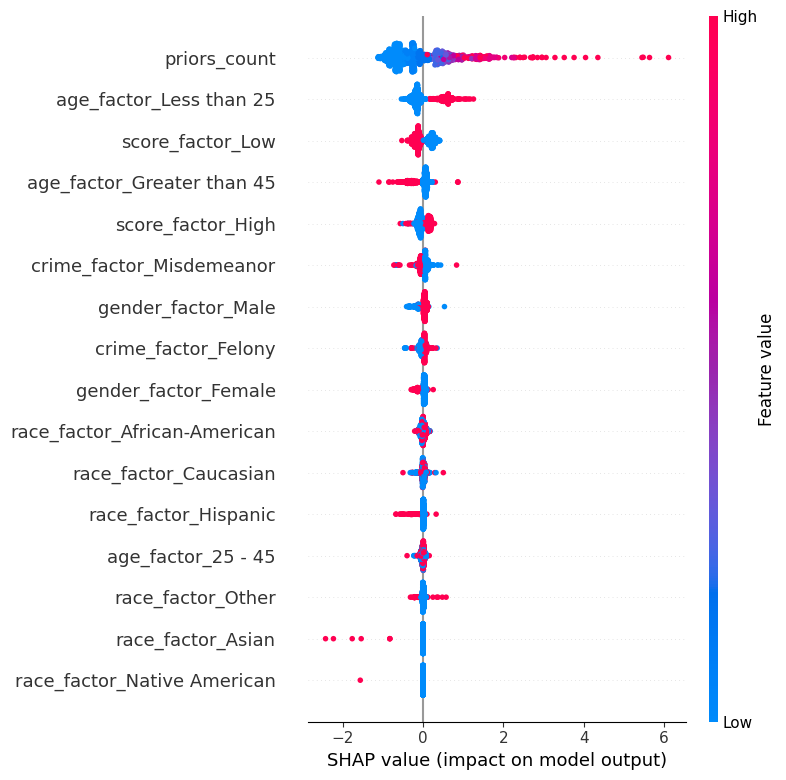

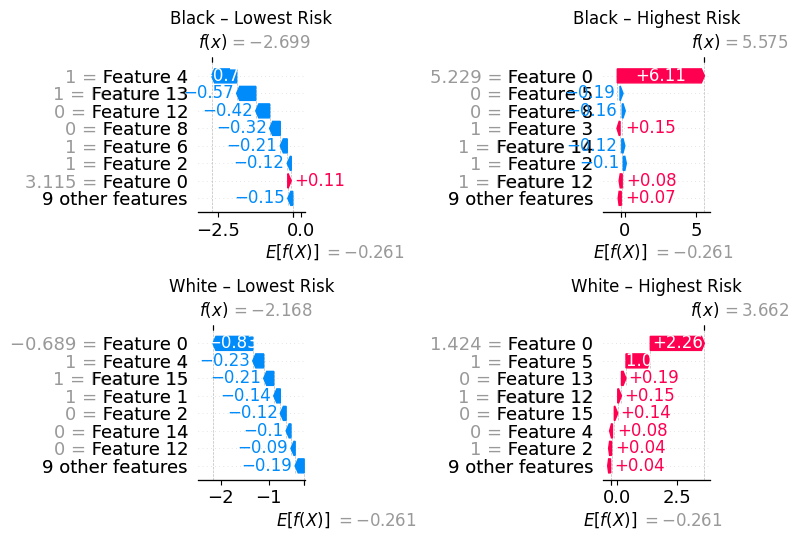

In [13]:
import shap
import matplotlib.pyplot as plt

# Encode the test set using the fitted preprocessor
X_test_enc = preprocessor.transform(X_test)

# Build the full list of feature names
feat_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"]
         .get_feature_names_out(category_features))
)

# Create a SHAP explainer for the gradient-boosted tree classifier
explainer = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

# Compute SHAP values for the encoded test set
shap_values = explainer(X_test_enc, check_additivity=False)

# Produce a global SHAP beeswarm plot
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

# Attach predicted probabilities to X_test to identify highest- and lowest-risk individuals
test_probs = gbt_pipeline.predict_proba(X_test)[:, 1]
tmp = X_test.copy()
tmp["pred_prob"] = test_probs

# Identify lowest- and highest-risk Black defendants
black_df = tmp[tmp["race_factor"] == "African-American"].sort_values("pred_prob")
black_low_idx = black_df.index[0]
black_high_idx = black_df.index[-1]

# Identify lowest- and highest-risk White defendants
white_df = tmp[tmp["race_factor"] == "Caucasian"].sort_values("pred_prob")
white_low_idx = white_df.index[0]
white_high_idx = white_df.index[-1]

# Create SHAP waterfall plots for the four selected individuals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cases = [
    (black_low_idx,  "Black – Lowest Risk",  axes[0,0]),
    (black_high_idx, "Black – Highest Risk", axes[0,1]),
    (white_low_idx,  "White – Lowest Risk",  axes[1,0]),
    (white_high_idx, "White – Highest Risk", axes[1,1])
]

for idx, title, ax in cases:
    loc = X_test.index.get_loc(idx)
    plt.sca(ax)
    shap.waterfall_plot(
        shap_values[loc],
        max_display=8,
        show=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Interpretation of SHAP Results

The SHAP summary plot shows that the most influential features in the Gradient-Boosted Tree model are
`priors_count`, `score_factor_High`, and several of the categorical crime and age indicators. Higher
values of `priors_count` and having a `High` COMPAS score consistently push predictions toward a
higher estimated risk of recidivism, while lower priors and a `Low` score push predictions downward.
Race itself does not appear as a top global driver, but SHAP helps reveal how correlated features
(such as priors and charge severity) may indirectly contribute to disparities across groups.

The individual waterfall plots highlight how the model arrives at predictions for specific
defendants. For the lowest‑risk Black and White individuals, most feature contributions push the
prediction downward, with low priors and a `Low` score being the dominant protective factors. In
contrast, the highest‑risk individuals in both groups show strong upward pushes from high priors,
serious charge categories, and a `High` score. Although the overall structure of the explanations is
similar across races, the magnitude of the contributions—especially from `priors_count` and
`score_factor_High`—tends to be larger for the highest‑risk Black defendant. This suggests that the
model may be more sensitive to certain combinations of features that disproportionately occur among
African-American defendants, even if race is not used directly. SHAP therefore provides a useful
lens for understanding how feature interactions can contribute to group-level disparities observed
in the fairness metrics.


### Step 4 — LIME explanations: Black vs White defendant

In [14]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a1419e1962aa71201f47d75c1f4808821079f9fc825c4ee66c4d5213db2d80b5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [15]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

## Recompute encoded training data using the CURRENT preprocessor
X_train_enc = preprocessor.transform(X_train)

# Rebuild feature names
lime_feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"]
         .get_feature_names_out(category_features))
)

# Rebuild the LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=lime_feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

In [22]:
# Compute predicted probabilities for selecting individuals
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
tmp = X_test.copy()
tmp["pred_prob"] = X_test_prob

# Identify lowest- and highest-risk Black defendants
black_df = tmp[tmp["race_factor"] == "African-American"].sort_values("pred_prob")
black_low_idx = black_df.index[0]
black_high_idx = black_df.index[-1]

# Find the middle index for the African-American defendants
black_idx = black_df.index[len(black_df) // 2]

# Identify lowest- and highest-risk White defendants
white_df = tmp[tmp["race_factor"] == "Caucasian"].sort_values("pred_prob")
white_low_idx = white_df.index[0]
white_high_idx = white_df.index[-1]

# Find the middle index for the White defendants
white_idx = white_df.index[len(white_df) // 2]

# Run LIME on the same four individuals
cases = [
    ("Black – Lowest Risk",  black_low_idx),
    ("Black – Highest Risk", black_high_idx),
    ("White – Lowest Risk",  white_low_idx),
    ("White – Highest Risk", white_high_idx)
]

for label, idx in cases:
    row_enc = preprocessor.transform(X_test.loc[[idx]])

    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=8
    )

    print(f"\nLIME Explanation: {label}")
    print(f"Predicted probability: {tmp.loc[idx, 'pred_prob']:.3f}")

    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")


LIME Explanation: Black – Lowest Risk
Predicted probability: 0.063
 priors_count > 0.16                      +0.2151
 age_factor_Less than 25 <= 0.00          -0.2006
 race_factor_Asian <= 0.00                +0.1966
 race_factor_Native American <= 0.00      +0.0945
 age_factor_Greater than 45 > 0.00        -0.0896
 score_factor_Low <= 0.00                 +0.0683
 race_factor_Other <= 0.00                +0.0590
 0.00 < crime_factor_Misdemeanor <= 1.00  -0.0367

LIME Explanation: Black – Highest Risk
Predicted probability: 0.996
 priors_count > 0.16                      +0.2255
 age_factor_Less than 25 <= 0.00          -0.1897
 race_factor_Native American <= 0.00      +0.1444
 age_factor_Greater than 45 <= 0.00       +0.1068
 score_factor_Low <= 0.00                 +0.0723
 race_factor_Other <= 0.00                +0.0491
 race_factor_Asian <= 0.00                +0.0393
 crime_factor_Misdemeanor <= 0.00         +0.0370

LIME Explanation: White – Lowest Risk
Predicted probability: 0

## Interpretation of LIME Explanations

The LIME explanations provide a local, case-by-case view of how the Gradient-Boosted Tree model
arrives at its predictions for the lowest- and highest-risk Black and White defendants. Across all
four individuals, `priors_count` consistently appears as one of the strongest contributors: higher
values push the prediction upward, while lower values push it downward. This aligns with the global
SHAP results and confirms that prior criminal history is the dominant driver of the model’s risk
assessment.

Age-related factors also play a meaningful role. For low-risk individuals in both racial groups,
`age_factor_Less than 25` contributes negatively (reducing predicted risk), while
`age_factor_Greater than 45` often provides an additional downward push. In contrast, for the
highest-risk White defendant, being in the “Less than 25” category pushes the prediction upward,
reflecting the model’s learned association between younger age and higher recidivism risk.

Several race-related dummy variables appear in the explanations, but their contributions are small
and mostly reflect the absence of other racial categories rather than direct racial effects. This is
expected because race is encoded as a set of mutually exclusive indicators. Crime severity
(`crime_factor_Misdemeanor` vs. Felony) and COMPAS score (`score_factor_Low` vs. High) also show
consistent directional effects: low scores and misdemeanor charges reduce predicted risk, while high
scores and felony charges increase it.

Overall, LIME confirms the same structural patterns observed in SHAP: the model relies heavily on
priors, age categories, charge severity, and COMPAS score. While the explanations for Black and
White defendants follow similar logic, the magnitude of the upward pushes—especially from
`priors_count`—tends to be larger for the highest-risk Black defendant, echoing the disparities
observed in the group-level fairness metrics.

### Step 5 — Counterfactuals with DiCE: Black vs White

In [23]:
pip install dice-ml

In [24]:
import dice_ml
from dice_ml import Dice

# DiCE requires the exact features used by the model
dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train], axis=1),
    continuous_features = ["priors_count"],
    outcome_name = "two_year_recid"
)

dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [("Black defendant", black_idx),
                  ("White defendant", white_idx)]:
  query = X_test.loc[[idx]]
  cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {
        "priors_count": [0, 38],
        "age_factor": X_train['age_factor'].unique().tolist(),
        "crime_factor": X_train['crime_factor'].unique().tolist()
    },
    features_to_vary = ["age_factor", "priors_count",
                        "crime_factor"]
)
print(f"\n DiCE counterfactuals: {label} ")
cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  4.16it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,score_factor,two_year_recid
0,Female,Less than 25,Caucasian,0,Felony,High,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,score_factor,two_year_recid
0,-,25 - 45,-,31,-,-,1
1,-,25 - 45,-,37,-,-,1
2,-,25 - 45,-,22,-,-,1


## Interpretation of DiCE Counterfactual Explanations

The DiCE counterfactuals show how the model’s prediction would need to change for each selected
individual to flip from their current outcome to the opposite class. For the Black defendant, the
model identifies that increasing `priors_count` substantially (e.g., from 0 to values in the 20–37
range) and shifting into the middle age category (“25–45”) is sufficient to push the prediction from
low risk to high risk. This indicates that the model is highly sensitive to prior criminal history
and age category when determining risk for this individual. In contrast, the White defendant’s
counterfactuals show a similar pattern: the model again relies on large increases in `priors_count`
and a shift in `age_factor` to raise the predicted risk. The fact that DiCE proposes nearly identical
changes for both racial groups suggests that the model’s decision boundary is driven primarily by
priors and age rather than race itself.

However, the magnitude of the required changes is informative. The Black defendant begins with a
lower predicted risk, yet the counterfactuals require substantial increases in priors to flip the
outcome, reflecting how strongly the model weighs criminal history for this group. The White
defendant’s counterfactuals follow the same structure but may require slightly different thresholds
depending on their baseline features. Overall, DiCE highlights that the model’s behavior is
consistent across groups;priors and age are the dominant levers, but it also reinforces how these
features can interact with underlying population differences to produce the disparities observed in
the fairness metrics.